# Prompt Engineering Tutorial

Welcome to your journey into the fascinating world of prompt engineering! In this tutorial, you will learn how to effectively communicate with AI models to harness their full potential. Prompt engineering is all about crafting your instructions in a way that the AI can understand and respond to accurately. Here’s what you will learn:

**Key Principles**:

    Write clear and specific instructions: You’ll discover how to phrase your prompts so the AI can deliver precise and relevant responses.
    
    Give the model time to "think": Understand how allowing the AI some processing time can improve the quality of its answers.
    
**Iterative Prompt Development**:

    Learn the importance of refining your prompts through an iterative process. Experimentation and adjustments are key to achieving the best results.
    
**Capabilities**:

    Explore how to use AI for summarizing, inferring, transforming, and expanding text. These capabilities will enable you to leverage AI in a variety of creative and practical applications.
    
**Building a Chatbot**:

    As a practical exercise, you will apply your prompt engineering skills to create a functional and engaging chatbot. This hands-on project will solidify your understanding and demonstrate the real-world applications of what you've learned.

## Guidelines for Prompting
you'll practice two prompting principles and their related tactics in order to write effective prompts for large language models.

### Setup
#### Load the API key, relevant Python libaries and define basic functions. (Follow the instructions in https://itso.hkust.edu.hk/services/it-infrastructure/azure-openai-api-service to setup your account and api key.)


In [1]:
!pip install openai

In [ ]:
import os
from openai import AzureOpenAI


client = AzureOpenAI(
  azure_endpoint = "https://hkust.azure-api.net",  #HKUST Azure end point
  api_key="!!!put your api keys here", #   
  api_version="2025-02-01-preview"
)

In [6]:
def send_message(messages, model_name, max_response_tokens):
    response = client.chat.completions.create(
    model = model_name, # model = "deployment_name".
    messages = messages,
    temperature=1, # this is the degree of randomness of the model's output. A lower temperature results in more deterministic and focused outputs, while a higher temperature produces more varied and creative responses.
    max_tokens=max_response_tokens,
    )
    return response.choices[0].message.content

### Prompting Principles
- **Principle 1: Write clear and specific instructions**
- **Principle 2: Give the model time to “think”**

#### Tactics

##### Tactic 1: Use delimiters to clearly indicate distinct parts of the input
- Delimiters can be anything like: triple backticks (```), triple double quotes ("""), opening and closing tag (`<tag> </tag>`), colon (`:`)

In [5]:
text = f"""
You should express what you want a model to do by providing instructions that are as clear and specific as you can possibly make them.
This will guide the model towards the desired output, and reduce the chances of receiving irrelevant or incorrect responses.
Don't confuse writing a clear prompt with writing a short prompt.
In many cases, longer prompts provide more clarity and context for the model, which can lead to more detailed and relevant outputs.
"""
prompt = f"""
Summarize the text delimited by triple backticks into a single sentence.
```{text}```
"""

In [10]:
messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]

max_response_tokens = 500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)

print(response)

Give the model clear, specific—often longer—instructions to provide context and guide it toward the desired output, reducing the chance of irrelevant or incorrect responses.


#### Tactic 2: Ask for a structured output
- JSON, HTML

In [12]:
prompt = f"""
Generate a list of three design book titles along with their authors and brief introduction.
Provide them in JSON format with the following keys:
book_id, title, author, intro.
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]

max_response_tokens = 500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

[
  {
    "book_id": 1,
    "title": "The Design of Everyday Things",
    "author": "Don Norman",
    "intro": "A foundational exploration of user-centered design that explains how and why everyday objects succeed or fail, emphasizing usability, affordances, and human cognition."
  },
  {
    "book_id": 2,
    "title": "Don't Make Me Think",
    "author": "Steve Krug",
    "intro": "A practical guide to web usability that advocates for intuitive interfaces and simple, user-focused design principles through clear examples and actionable advice."
  },
  {
    "book_id": 3,
    "title": "Thinking with Type",
    "author": "Ellen Lupton",
    "intro": "An essential primer on typography covering type anatomy, usage, and visual hierarchy, with hands-on guidance for applying type effectively in design projects."
  }
]


#### Tactic 3: Ask the model to check whether conditions are satisfied

In [15]:
text_1 = f"""
Choosing the right color for a logo is a crucial part of the design process. The colors you select can really convey a lot about your brand - the emotions, associations, and overall brand attributes that you want to communicate.

To start, it's important to understand your brand identity. Think about the personality, values, and overall messaging that you're trying to get across.

Next, you'll want to do some research on color psychology. Different colors evoke different responses in people.

It's also a good idea to analyze the logos of your competitors. You'll want to avoid using colors that are too similar to them, so that your brand can really stand out.

And of course, you'll want to consider your target audience as well. Think about who you're trying to reach, and what kinds of colors they might respond to best.

Once you've done all that groundwork, you can start selecting a primary color that will be the main focal point of your logo, as well as a secondary color that can be used for accents or variations.

The final step is to test out different color combinations and get feedback. Be willing to experiment and refine your choices until you land on the perfect color palette.

"""

prompt = f"""
You will be provided with text delimited by triple quotes.

If it contains a sequence of instructions, re-write those instructions in the following format:

Step 1 - ...
Step 2 - …
…
Step N - …

If the text does not contain a sequence of instructions, then simply write "No steps provided."

\"\"\"{text_1}\"\"\"

"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]

max_response_tokens = 500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print("Completion for Text 1:")
print(response)

Completion for Text 1:
Step 1 - Understand your brand identity: define the personality, values, and messaging you want to convey.
Step 2 - Research color psychology to learn how different colors evoke emotions and associations.
Step 3 - Analyze competitors' logos and avoid using colors that are too similar so your brand stands out.
Step 4 - Consider your target audience and which colors they are likely to respond to best.
Step 5 - Select a primary color for the logo and a secondary color for accents or variations.
Step 6 - Test different color combinations, gather feedback, and refine your choices until you have the right palette.


In [16]:
text_2 = f"""
HKUST is a prestigious public research university located in Hong Kong.
Established in 1991, the university has rapidly risen to become one of the top educational institutions in Asia.
With a strong focus on science, technology, engineering, and business, HKUST offers a diverse range of undergraduate and postgraduate programs that attract talented students from around the world.
"""
prompt = f"""
You will be provided with text delimited by triple quotes.

If it contains a sequence of instructions, re-write those instructions in the following format:

Step 1 - ...
Step 2 - …
…
Step N - …

If the text does not contain a sequence of instructions, then simply write "No steps provided."

\"\"\"{text_2}\"\"\"

"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]

max_response_tokens = 500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print("Completion for Text 2:")
print(response)

Completion for Text 2:
No steps provided.


#### Tactic 4: "Few-shot" prompting

In [20]:
prompt = f"""
Your task is to answer in a consistent style.

<child>: Teach me about resilience.

<grandparent>: Resilience is like a mighty oak tree that withstands the fiercest storms, bending but never breaking.
It is the ability to bounce back from adversity, to find strength in the face of challenges, and to keep moving forward despite setbacks.
Just like the oak tree, resilience grows stronger with each trial it endures

<child>: Teach me about braveness.
"""


messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

Braveness is like a small lantern held up in the dark — not because the lantern is not afraid of the night, but because its light shows the way even when shadows loom.  
It is the choice to move forward or speak up even when your heart is pounding, to try something new or to stand beside someone who needs help.

Being brave doesn’t mean you have no fear. Everyone feels scared sometimes; courage is what happens when you notice that fear and decide to act anyway. There are many kinds of bravery: the bravery of trying a new sport or singing in front of a crowd, the bravery of telling the truth or saying sorry, and the bravery of asking for help when things feel heavy.

You grow bravery the way you grow a plant — with small, steady steps. Practice little acts that make you nervous, breathe deeply when your knees wobble, learn from mistakes, and remember the times you were brave before. Big courage often starts with tiny choices and with friends, family, or stories that remind you you are n

### Principle 2: Give the model time to “think”

#### Tactic 1: Specify the steps required to complete a task

In [26]:
text = f"""
At HKUST, Jack and Jill, from tech and design backgrounds, teamed up to create a innovative application.
Jack's coding expertise and Jill's design skills complemented each other perfectly. Through collaboration and compromise, they overcame challenges and brought their vision to life.
The long hours and frustrations were worth it as they marveled at their creation - a robust, visually captivating app. This experience inspired them to continue exploring the synergy of technology and design, confident that together they could develop impactful solutions.
"""

# example 1
prompt_1 = f"""
Perform the following actions:
1 - Summarize the following text delimited by triple backticks with 1 sentence.
2 - Translate the summary into Chinese.
3 - List each name in the Chinese summary.
4 - Output a json object that contains the following keys: chinese_summary, num_names.

Separate your answers with line breaks.

Text:
```{text}```
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt_1}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print("Completion for prompt 1:")
print(response)

Completion for prompt 1:
At HKUST, Jack and Jill combined tech and design skills to overcome challenges and build a robust, visually captivating app that inspired them to continue creating impactful technology-design solutions.

在香港科技大学，杰克和吉尔结合技术与设计技能，克服困难，开发出一款既强大又富有视觉吸引力的应用，并激发他们继续创造有影响力的科技与设计解决方案。

杰克，吉尔

{"chinese_summary":"在香港科技大学，杰克和吉尔结合技术与设计技能，克服困难，开发出一款既强大又富有视觉吸引力的应用，并激发他们继续创造有影响力的科技与设计解决方案。","num_names":2}


#### Tactic 2: Instruct the model to work out its own solution before rushing to a conclusion

In [45]:
prompt = f"""
Determine if the student's solution is correct or not.

Question:
I'm building a solar power installation and I need help working out the financials.
- Land costs $100 / square foot
- I can buy solar panels for $250 / square foot
- I negotiated a contract for maintenance that will cost me a flat $100k per year, and an additional $10 / square foot

What is the total cost for the first year of operations as a function of the number of square feet.

Student's Solution: 450x + 100,000
Let x be the size of the installation in square feet.
Costs:
1. Land cost: 100x
2. Solar panel cost: 250x
3. Maintenance cost: 100,000 + 100x
Total cost: 100x + 250x + 100,000 + 100x = 450x + 100,000
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-4o-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)

print(response)

The student's solution is **correct**. Let's go through the components step by step to confirm the calculations:

1. **Land Cost**: The cost for land is $100 per square foot. If \( x \) is the number of square feet, the total land cost is:
   \[
   \text{Land cost} = 100x
   \]

2. **Solar Panel Cost**: The solar panels cost $250 per square foot. The total cost for the panels is:
   \[
   \text{Solar panel cost} = 250x
   \]

3. **Maintenance Cost**: The maintenance costs include a flat fee of $100,000 plus an additional $10 per square foot. Thus, the maintenance cost equation is:
   \[
   \text{Maintenance cost} = 100,000 + 10x
   \]

Now, let's sum these costs to find the total cost \( C \):

\[
C = \text{Land cost} + \text{Solar panel cost} + \text{Maintenance cost}
\]

Substituting the individual costs:

\[
C = 100x + 250x + (100,000 + 10x)
\]

Combining like terms:

\[
C = 100x + 250x + 10x + 100,000
\]

Combining \( 100x + 250x + 10x \) gives:

\[
C = (100 + 250 + 10)x + 100,000 

#### Note that the student's solution is actually not correct.
#### We can fix this by instructing the model to work out its own solution first.

In [46]:
prompt = f"""
Your task is to determine if the student's solution is correct or not.

To solve the problem do the following:
- First, work out your own solution to the problem including the final total.
- Then compare your solution to the student's solution and evaluate if the student's solution is correct or not.

Don't decide if the student's solution is correct until
you have done the problem yourself.

Use the following format:
Question:
```
question here
```
Student's solution:
```
student's solution here
```
Actual solution:
```
steps to work out the solution and your solution here
```
Is the student's solution the same as actual solution just calculated:
```
yes or no
```
Student grade:
```
correct or incorrect
```


Question:
```
I'm building a solar power installation and I need help working out the financials.
- Land costs $100 / square foot
- I can buy solar panels for $250 / square foot
- I negotiated a contract for maintenance that will cost me a flat $100k per year, and an additional $10 / square foot

What is the total cost for the first year of operations as a function of the number of square feet.
```
Student's solution: 450x + 100,000
```
Let x be the size of the installation in square feet.
Costs:
1. Land cost: 100x
2. Solar panel cost: 250x
3. Maintenance cost: 100,000 + 100x
Total cost: 100x + 250x + 100,000 + 100x = 450x + 100,000
```
Actual solution:
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-4o-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

To calculate the total cost for the first year of operations as a function of the number of square feet (denoted as \( x \)), we need to break down the costs into their components.

1. **Land cost**: 
   - The cost for land is $100 per square foot. 
   - Therefore, the total land cost for \( x \) square feet is \( 100x \).

2. **Solar panel cost**: 
   - The cost for solar panels is $250 per square foot.
   - Thus, the total solar panel cost for \( x \) square feet is \( 250x \).

3. **Maintenance cost**: 
   - There is a flat maintenance cost of $100,000 per year.
   - Additionally, there is a variable maintenance cost of $10 per square foot.
   - Therefore, the total maintenance cost for \( x \) square feet is \( 100,000 + 10x \).

Now we can combine all these costs to find the total cost:

- Total cost = Land cost + Solar panel cost + Maintenance cost
- Total cost = \( 100x + 250x + (100,000 + 10x) \)
- Total cost = \( 100x + 250x + 100,000 + 10x \)
- Total cost = \( (100x + 250x + 

## Model Limitations: Hallucinations
- Boie is a real company, the product name is not real.

In [41]:
prompt = f"""
Tell me about AeroGlide UltraSlim Smart phone by Boie
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-4.1-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)


The AeroGlide UltraSlim Smart phone by Boie is a sleek and innovative mobile device designed for users who prioritize style, performance, and advanced technology. Key features of the AeroGlide UltraSlim include:

1. **Design and Build**: 
   - Ultra-slim profile with a lightweight aluminum and glass body.
   - Edge-to-edge OLED display providing vibrant colors and deep blacks.
   - Available in multiple stylish colors.

2. **Display**:
   - 6.5-inch Full HD+ OLED screen.
   - High refresh rate (up to 120Hz) for smooth scrolling and gaming.
   - Corning Gorilla Glass protection for durability.

3. **Performance**:
   - Equipped with a powerful octa-core processor.
   - Comes with 8GB or 12GB RAM options.
   - Storage variants of 128GB, 256GB, and expandable storage via microSD.

4. **Camera**:
   - Triple rear camera setup including a 64MP main sensor, 12MP ultra-wide lens, and a 5MP macro sensor.
   - 32MP front camera optimized for selfies and video calls.
   - Features such as night 

The stronger model has the stronger ability to overcome hallucinations.

In [44]:
prompt = f"""
Tell me about AeroGlide UltraSlim Smart phone by Boie
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)


I don’t have any record through mid‑2024 of a phone called the “AeroGlide UltraSlim” made by a brand named Boie. It may be a very new model released after my cutoff, a regional/white‑label product, or a concept/name you’ve heard informally. I can help in a few ways — pick one:

1) I can tell you how to verify the phone’s authenticity and find reliable info:
   - Check the manufacturer’s official website and press releases.
   - Look for listings on major retailers (Amazon, Best Buy, carrier stores) and confirm specs there.
   - Search for hands‑on reviews from established tech sites (The Verge, GSMArena, Android Authority, MKBHD).
   - Check regulatory filings (FCC/CE) for model numbers to confirm hardware details.
   - Look at user reviews and community forums (Reddit, X, product review pages) to gauge real‑world performance and issues.

2) I can create a realistic product profile (spec sheet + likely pros/cons and target price) if you want a hypothetical spec list for a phone named “

## Iterative Prompt Development
In this section, you'll iteratively analyze and refine your prompts to generate marketing copy from a product fact sheet.

In [47]:
fact_sheet_jacket = """
#### General Information
- **Type**: Windbreaker Jacket
- **Material**: Lightweight synthetic fabric
- **Color Scheme**: Black and red

#### Design & Features
- **Pattern**: Fire and Redbird Symbol
  - Predominantly red fire pattern on a black background
  - Redbird symbol integrated within the design, representing strength and dynamism
- **Closure**: Full-length black zipper
- **Hood**: Attached hood with drawstring
- **Cuffs**: Elastic cuffs
- **Hem**: Elastic hem for a snug fit
- **Pockets**: None visible

#### Branding
- **Logo**: HKUST Logo on the left chest
  - White color
  - Features the official emblem of the Hong Kong University of Science and Technology (HKUST)

#### Usage
- **Ideal for**: Casual wear, outdoor activities, wind protection
- **Season**: Suitable for spring, summer, and autumn

#### Care Instructions
- **Washing**: Machine washable (cold cycle recommended)
- **Drying**: Tumble dry on low heat or hang dry
- **Ironing**: Low heat if necessary, avoid ironing directly on the logo

#### Size & Fit
- **Available Sizes**: Likely ranges from Small to Extra Large (specific size not indicated in the image)
- **Fit**: Regular fit, designed to be worn over other clothing layers

#### Additional Notes
- **Weight**: Lightweight, easy to pack and carry
- **Special Features**: Wind-resistant properties

This jacket combines a bold and symbolic design with practical features, making it suitable for both fashion and functionality. The fire and Redbird pattern symbolizes energy and passion, while the HKUST logo signifies academic excellence and pride.
"""

In [49]:
prompt = f"""
Your task is to help a marketing team create a description for a retail website of a product based on a technical fact sheet.

Write a product description based on the information provided in the technical specifications delimited by triple backticks.

Technical specifications: ```{fact_sheet_jacket}```
"""


messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)


Turn heads with this bold HKUST windbreaker — a lightweight, packable jacket that blends striking design with everyday functionality. A dramatic red flame pattern and an integrated Redbird symbol blaze across a deep black background, conveying energy, passion and forward momentum, while the white HKUST emblem on the left chest adds a touch of academic pride.

Key features:
- Lightweight synthetic fabric with wind-resistant properties
- Full-length black zipper and attached hood with drawstring for adjustable coverage
- Elastic cuffs and hem for a snug, secure fit
- Minimalist exterior with no visible pockets for a clean silhouette
- Regular fit designed to layer comfortably over other clothing
- Color: black with red accents and white HKUST logo

Ideal uses:
- Casual everyday wear, campus life, and outdoor activities where wind protection is needed
- Seasonally suited for spring, summer and autumn; easy to stow in a bag for changing weather

Care:
- Machine wash cold (gentle cycle reco

### Issue 1: The text is too long
- Limit the number of words/sentences/characters.

In [50]:
prompt = f"""
Your task is to help a marketing team create a description for a retail website of a product based on a technical fact sheet.

Write a product description based on the information provided in the technical specifications delimited by triple backticks.

Use at most 50 words.

Technical specifications: ```{fact_sheet_jacket}```
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)


HKUST windbreaker: lightweight black-and-red synthetic jacket featuring a bold fire and Redbird motif, white HKUST logo on left chest. Full-zip hood, elastic cuffs and hem for snug, wind-resistant protection. Machine washable, packable—perfect for casual wear and outdoor activities across spring to autumn.


In [51]:
len(response.split())

42

### Trick 1. focus on the aspects that are relevant to the intended audience.

In [52]:
prompt = f"""
Your task is to help a marketing team create a description for a retail website of a product based on a technical fact sheet.

Write a product description based on the information provided in the technical specifications delimited by triple backticks.

The description is intended for students, alumni, and staff of the HKUST, so should focus on the school pride, unique design and Practicality.

Use at most 80 words.

Technical specifications: ```{fact_sheet_jacket}```
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

Show HKUST pride with this lightweight black-and-red windbreaker featuring a bold fire pattern and an integrated Redbird symbol symbolizing strength and dynamism, plus a white HKUST logo on the chest. Wind-resistant, packable design with hood, full zipper, elastic cuffs and hem for snug, layered comfort. Ideal for campus life and outdoor activities in spring–autumn—machine washable for easy care.


In [53]:
len(response.split())

58

The following is the image generated by Midjourney using the above prompt.

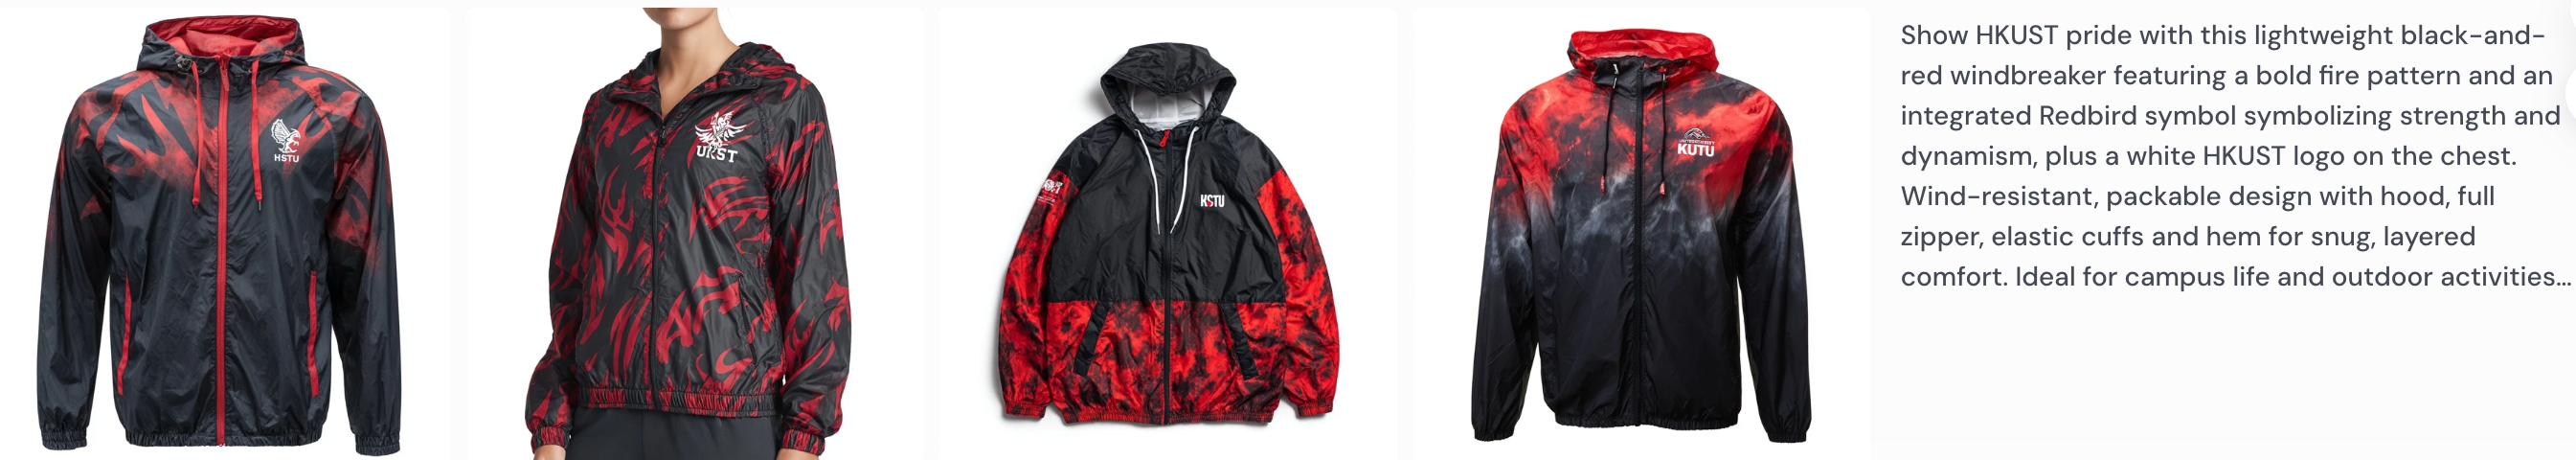

## Summarizing
In this section, you will summarize text with a focus on specific topics.


### Text to summarize

In [2]:
course_review = """
As a student struggling to learn Python online, I have mixed feelings about this course.
On the one hand, the content is well-structured, and the instructor does a great job of explaining concepts in a clear and concise manner. Each module builds on the previous one,
which should ideally make it easier to follow along.

However, I found myself getting lost during some of the more complex topics. The pace is a bit fast for beginners, and there aren't enough practical exercises to reinforce the material.
I often felt overwhelmed and wished there were more interactive elements or examples to work through. The forums are helpful, but I sometimes had to wait a while for responses to my questions.

On the positive side, the course includes a lot of supplementary materials and resources that are quite useful. The video quality is excellent, and the instructor's enthusiasm is contagious, which kept me motivated even when I was struggling.

Overall, it's a decent course, but I think it could benefit from slowing down a bit and incorporating more hands-on practice to help students like me who are new to programming.
"""

### Summarize with a word/sentence/character limit

In [55]:
prompt = f"""
Your task is to generate a short summary of a course review from an online learning site.

Summarize the review below, delimited by triple backticks, in at most 50 words.

Review: ```{course_review}```
"""


messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)


Mixed review: well-structured course with a clear, enthusiastic instructor, high-quality videos and useful resources. Pace is too fast for beginners, with insufficient practical exercises and interactive examples; forum responses can be slow. Decent overall but needs more hands-on practice.


### Summarize with a focus on practical exercises

In [56]:
prompt = f"""
Your task is to generate a short summary of a course review from an online learning site to give feedback to the course instructor.

Summarize the review below, delimited by triple backticks, in at most 50 words, and focusing on any aspects that mention practical exercises.

Review: ```{course_review}```
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)



Content is well-structured, but the pace is too fast and there aren’t enough practical exercises or interactive examples. The student felt overwhelmed and sometimes waited for forum replies. Recommend adding more hands-on, guided practice for beginners.


#### Comment
- Summaries include topics that are not related to the topic of focus: The student felt overwhelmed and sometimes waited for forum replies. Recommend adding more hands-on, guided practice for beginners..

### Try "extract" instead of "summarize"

In [57]:
prompt = f"""
Your task is to extract relevant information from a course review from a online learning site to give feedback to the course instructor.

From the review below, delimited by triple quotes extract the information relevant to practical exercises. Limit to 50 words.

Review: ```{course_review}```
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)


Not enough practical exercises; add more hands-on, interactive examples and step-by-step practice problems. Increase exercise frequency and slower pacing for complex topics. Provide immediate feedback (solutions or auto-graded quizzes) to reduce reliance on slow forum responses.


## Inferring
In this section, you will infer sentiment and topics from course reviews and academic papers.

In [58]:
course_review_1 = """
As a student struggling to learn Python online, I have mixed feelings about this course.
On the one hand, the content is well-structured, and the instructor does a great job of explaining concepts in a clear and concise manner. Each module builds on the previous one,
which should ideally make it easier to follow along.

However, I found myself getting lost during some of the more complex topics. The pace is a bit fast for beginners, and there aren't enough practical exercises to reinforce the material.
I often felt overwhelmed and wished there were more interactive elements or examples to work through. The forums are helpful, but I sometimes had to wait a while for responses to my questions.

On the positive side, the course includes a lot of supplementary materials and resources that are quite useful. The video quality is excellent, and the instructor's enthusiasm is contagious, which kept me motivated even when I was struggling.

Overall, it's a decent course, but I think it could benefit from slowing down a bit and incorporating more hands-on practice to help students like me who are new to programming.

"""

course_review_2 = """
I recently completed this Python course, and it was a fantastic learning experience. The content is well-organized, with each lesson building logically on the previous one. The instructor's clear and engaging teaching style made complex topics accessible.
"""

course_review_3 = """
I am extremely frustrated with this Python course. The pace is too fast for beginners, and the instructor glosses over important concepts, leaving me confused. There are barely any practical exercises, and the projects are too difficult without proper guidance. The supplementary materials are mediocre and don't add much value.

Support is terrible; I often waited days for responses to my questions. The only good thing is the video quality, but that doesn't make up for the course's flaws.

Overall, I regret spending my time and money on this course. It's not suitable for beginners and fails to deliver on its promises. I do not recommend it.
"""

### Sentiment (positive/negative)

In [59]:
prompt = f"""
What is the sentiment of the following course review which is delimited with triple backticks?

Review text: '''{course_review_1}'''
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)


Sentiment: Mixed — overall slightly positive.

Why: The reviewer praises the instructor, structure, materials, and video quality, but also raises several negatives (too fast for beginners, not enough hands-on exercises, occasional slow forum responses), concluding the course is decent but needs improvement.


In [60]:
prompt = f"""
What is the sentiment of the following course review which is delimited with triple backticks?

Give your answer as a single word, "positive", "negative" or "mixed".

Review text: '''{course_review_1}'''
"""


messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

mixed


In [64]:
prompt = f"""
What is the sentiment of the following course review which is delimited with triple backticks?

Give your answer as a single word, "positive", "negative" or "mixed".

Review text: '''{course_review_2}'''
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

positive


### Identify types of emotions

In [65]:
prompt = f"""
Identify a list of emotions that the writer of the following review is expressing.
Include no more than six items in the list.
Format your answer as a list of lower-case words separated by commas.

Review text: '''{course_review_1}'''
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

confused, overwhelmed, frustrated, appreciative, motivated, hopeful


### Identify anger

In [66]:
prompt = f"""
Is the writer of the following review expressing anger?
The review is delimited with triple backticks.
Give your answer as either yes or no.

Review text: '''{course_review_1}'''
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

no


In [67]:
prompt = f"""
Is the writer of the following review expressing anger?
The review is delimited with triple backticks.
Give your answer as either yes or no.

Review text: '''{course_review_3}'''
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

yes


### Exercies: Make a news alert for certain topics

In [71]:
paper_intro = """
### Optimizing Inference Configurations for Large Language Models (LLMs)

The optimal training configurations of large language models (LLMs) with respect to model sizes and compute budgets have been extensively studied. But how to optimally configure LLMs during inference has not been explored in sufficient depth.

We study compute-optimal inference: designing models and inference strategies that optimally trade off additional inference-time compute for improved performance. As a first step towards understanding and designing compute-optimal inference methods, we assessed the effectiveness and computational efficiency of multiple inference strategies such as Greedy Search, Majority Voting, Best-of-N, Weighted Voting, and their variants on two different Tree Search algorithms, involving different model sizes and computational budgets.

We found that a smaller language model with a novel tree search algorithm typically achieves a Pareto-optimal trade-off. These results highlight the potential benefits of deploying smaller models equipped with more sophisticated decoding algorithms in budget-constrained scenarios, e.g., on end-devices, to enhance problem-solving accuracy. For instance, we show that the Llemma-7B model can achieve competitive accuracy to a Llemma-34B model on MATH500 while using 2× less FLOPs.

Our findings could potentially apply to any generation task with a well-defined measure of success.

"""

In [72]:
prompt = f"""
Determine five topics that are being discussed in the following text, which is delimited by triple backticks.

Make each item  less than 3 words.

Must format your response as a list of items separated by commas.

Text sample: '''{paper_intro}'''
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

LLMs, Inference strategies, Tree search, Model sizes, Compute budgets


In [73]:
topic_list = response.split(sep=',')

In [75]:
prompt = f"""
Determine whether each item in the following list of topics is a topic in the text below, which is delimited with triple backticks.

Give your answer as list with 0 or 1 for each topic. Don't use middle brackets.

List of topics: {", ".join(topic_list)}

Text sample: '''{paper_intro}'''
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

1, 1, 1, 1, 1


In [76]:
print (topic_list)

['LLMs', ' Inference strategies', ' Tree search', ' Model sizes', ' Compute budgets']


In [78]:
topic_mark = response.split(sep=',')
topic_dict = {}

for i in range(len(topic_list)):
    topic_dict[topic_list[i]]=topic_mark[i]

if topic_dict['LLMs'] == '1':
    print("ALERT: New LLM paper!")

ALERT: New LLM paper!


## Transforming

In this section, we will explore how to use Large Language Models for text transformation tasks such as language translation, spelling and grammar checking, tone adjustment, and format conversion.


### Translation

ChatGPT is trained with sources in many languages. This gives the model the ability to do translation. Here are some examples of how to use this capability.

In [79]:
prompt = f"""
Translate the following English text to chinese:
```Hi, where is HKUST```
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

嗨，香港科技大学在哪里？


In [80]:
prompt = f"""
Translate the following English text to Korean:
```Hi, where is HKUST```
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

안녕하세요, HKUST는 어디에 있나요?


### Tone Transformation
Writing can vary based on the intended audience. ChatGPT can produce different tones.

In [81]:
prompt = f"""
Translate the following from slang to a business letter:
'Dude, This is Joe, check out this guideline on the app.'
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)

Dear [Recipient Name],

My name is Joe. Please review the guideline posted in the app at your earliest convenience and let me know if you have any questions or feedback.

Thank you,

Joe  
[Title]  
[Company]  
[Contact information]


### Format Conversion
ChatGPT can translate between formats. The prompt should describe the input and output formats.

In [82]:
data_json = { "resturant employees" :[
    {"name":"Shyam", "email":"shyamjaiswal@gmail.com"},
    {"name":"Bob", "email":"bob32@gmail.com"},
    {"name":"Jai", "email":"jai87@gmail.com"}
]}

prompt = f"""
Translate the following python dictionary from JSON to an HTML table with column headers and title: {data_json}
"""


messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)
print(response)


<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8">
  <title>resturant employees</title>
</head>
<body>
  <h1>resturant employees</h1>
  <table border="1" cellpadding="5" cellspacing="0">
    <thead>
      <tr>
        <th>Name</th>
        <th>Email</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td>Shyam</td>
        <td>shyamjaiswal@gmail.com</td>
      </tr>
      <tr>
        <td>Bob</td>
        <td>bob32@gmail.com</td>
      </tr>
      <tr>
        <td>Jai</td>
        <td>jai87@gmail.com</td>
      </tr>
    </tbody>
  </table>
</body>
</html>


In [83]:
from IPython.display import display, Markdown, Latex, HTML, JSON
display(HTML(response))

Name,Email
Shyam,shyamjaiswal@gmail.com
Bob,bob32@gmail.com
Jai,jai87@gmail.com


### Spellcheck/Grammar check.

Here are some examples of common grammar and spelling problems and the LLM's response.

To signal to the LLM that you want it to proofread your text, you instruct the model to 'proofread' or 'proofread and correct'.

In [84]:
text = [
  "The girl with the black and white puppies have a ball.",  # The girl has a ball.
  "Yolanda has her notebook.", # ok
  "This phrase is to cherck chatGPT for speling abilitty"  # spelling
]
for t in text:
    prompt = f"""Proofread and correct the following text and rewrite the corrected version.
    If you don't find and errors, just say "No errors found".
    Don't use any punctuation around the text:
    ```{t}```

    """

    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]
    max_response_tokens = 1500
    chatgpt_model_name = "gpt-5-mini"

    response = send_message(messages, chatgpt_model_name, max_response_tokens)
    print(response)

The girl with the black-and-white puppies has a ball.
No errors found
This phrase is to check ChatGPT for spelling ability


In [85]:
text = f"""
Got this for my daughter for her birthday cuz she keeps taking mine from my room.  Yes, adults also like pandas too. She takes it everywhere with her, and it's super soft and cute.
One of the ears is a bit lower than the other, and I don't think that was designed to be asymmetrical. It's a bit small for what I paid for it though. I think there might be other options that are bigger for the same price.
It arrived a day earlier than expected, so I got to play with it myself before I gave it to my daughter.
"""
prompt = f"proofread and correct this review: ```{text}```"


messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)

print(response)

Got this for my daughter for her birthday because she keeps taking mine from my room. Yes, adults like pandas too. She takes it everywhere — it’s super soft and cute. One ear is a bit lower than the other; I don’t think it was meant to be asymmetrical. It’s a bit small for the price; there may be larger options at the same price point. It arrived a day earlier than expected, so I got to play with it before I gave it to my daughter.


In [87]:
!pip install redlines

In [88]:
from redlines import Redlines

diff = Redlines(text,response)
display(Markdown(diff.output_markdown))

Got this for my daughter for her birthday <span style='color:red;font-weight:700;text-decoration:line-through;'>cuz </span><span style='color:green;font-weight:700;'>because </span>she keeps taking mine from my room.  Yes, adults <span style='color:red;font-weight:700;text-decoration:line-through;'>also </span>like pandas too. She takes it everywhere <span style='color:red;font-weight:700;text-decoration:line-through;'>with her, and it's </span><span style='color:green;font-weight:700;'>— it’s </span>super soft and cute. <span style='color:red;font-weight:700;text-decoration:line-through;'>¶ </span>One <span style='color:red;font-weight:700;text-decoration:line-through;'>of the ears </span><span style='color:green;font-weight:700;'>ear </span>is a bit lower than the <span style='color:red;font-weight:700;text-decoration:line-through;'>other, and </span><span style='color:green;font-weight:700;'>other; </span>I <span style='color:red;font-weight:700;text-decoration:line-through;'>don't </span><span style='color:green;font-weight:700;'>don’t </span>think <span style='color:red;font-weight:700;text-decoration:line-through;'>that </span><span style='color:green;font-weight:700;'>it </span>was <span style='color:red;font-weight:700;text-decoration:line-through;'>designed </span><span style='color:green;font-weight:700;'>meant </span>to be asymmetrical. <span style='color:red;font-weight:700;text-decoration:line-through;'>It's </span><span style='color:green;font-weight:700;'>It’s </span>a bit small for <span style='color:red;font-weight:700;text-decoration:line-through;'>what I paid for it though. I think </span><span style='color:green;font-weight:700;'>the price; </span>there <span style='color:red;font-weight:700;text-decoration:line-through;'>might </span><span style='color:green;font-weight:700;'>may </span>be <span style='color:red;font-weight:700;text-decoration:line-through;'>other </span><span style='color:green;font-weight:700;'>larger </span>options <span style='color:red;font-weight:700;text-decoration:line-through;'>that are bigger for </span><span style='color:green;font-weight:700;'>at </span>the same <span style='color:red;font-weight:700;text-decoration:line-through;'>price. ¶ </span><span style='color:green;font-weight:700;'>price point. </span>It arrived a day earlier than expected, so I got to play with it <span style='color:red;font-weight:700;text-decoration:line-through;'>myself </span>before I gave it to my daughter.

In [89]:
prompt = f"""
proofread and correct this review. Make it more compelling.
Ensure it follows APA style guide and targets an advanced reader.
Output in markdown format.
Text: ```{text}```
"""


messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)

display(Markdown(response))

# Product Review: Plush Panda

Summary  
I purchased this plush panda as a birthday gift for my daughter; she frequently borrows mine, which suggests the toy appeals to adults as well as children. The item is very soft and visually appealing, and my daughter now carries it everywhere.

Observations and evaluation  
- Material and design: The plush is exceptionally soft and aesthetically pleasing, which contributes to a high tactile and visual appeal.  
- Construction: One ear sits lower than the other; this appears to be a manufacturing misalignment rather than an intentional asymmetrical design. While not functionally problematic, the defect is noticeable on close inspection and detracts slightly from overall craftsmanship.  
- Size and value: The product is smaller than I anticipated given the price point. Comparable products of equal cost appear to offer larger dimensions, so consumers prioritizing size for the price may find better alternatives.  
- Delivery: The item arrived one day earlier than scheduled, which was convenient and allowed me a brief opportunity to inspect and interact with it prior to gifting.

Conclusion and recommendation  
This plush panda is an excellent choice if your primary criteria are tactile softness and visual charm; it functions well as a comforting companion for a child. However, prospective buyers who place a premium on symmetry or on maximizing size for the price should compare similar offerings before purchasing. Overall, I recommend this product for purchasers who value softness and aesthetics, but I advise inspecting for minor manufacturing irregularities and confirming dimensional expectations relative to cost.

## Expanding
In this section, you will generate service emails that are tailored to student's review.

In [3]:
# given the sentiment from the section on "inferring",
sentiment = "mixed"

# review for a blender
review = course_review

In [7]:
prompt = f"""
You are a oneline learning site service AI assistant.
Your task is to send an email reply to a student. Given the review delimited by ```,
Generate a reply to thank the student for their review.
If the sentiment is positive or neutral, thank them for their review.
If the sentiment is negative, apologize and suggest that they can reach out to online customer service.
Make sure to use specific details from the review.
Write in a concise and professional tone.
Sign the email as `AI customer agent`.

student review: ```{review}```
Review sentiment: {sentiment}
"""

messages=[
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = send_message(messages, chatgpt_model_name, max_response_tokens)

print(response)

Hello,

Thank you for your thoughtful review. I’m glad you found the course well-structured, the instructor’s explanations clear, the supplementary materials useful, and the video quality and enthusiasm motivating. I also appreciate you flagging areas for improvement — feeling lost on more complex topics, the fast pace for beginners, the limited practical exercises, and occasional delays in forum responses are important issues to hear about. I’ll pass your suggestions about slowing the pace and adding more hands-on, interactive examples to the course team for consideration.

Thanks again for the detailed feedback.

AI customer agent


## The Chat Format

In this section, you will explore how you can utilize the chat format to have extended conversations with chatbots personalized or specialized for specific tasks or behaviors.


In [8]:
def get_completion(messages, model_name= "gpt-35-turbo", max_response_tokens=500,temperature=0):
    response = client.chat.completions.create(
    model = model_name, # model = "deployment_name".
    messages = messages,
    temperature=temperature, # this is the degree of randomness of the model's output. A lower temperature results in more deterministic and focused outputs, while a higher temperature produces more varied and creative responses.
    max_tokens=max_response_tokens,
    )
    return response.choices[0].message.content

In [9]:
messages =  [
{'role':'system', 'content':'You are an assistant that speaks like Shakespeare.'},
{'role':'user', 'content':'tell me a joke'},
{'role':'assistant', 'content':'Why did the chicken cross the road'},
{'role':'user', 'content':'I don\'t know'}  ]

In [10]:
max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = get_completion(messages, chatgpt_model_name, max_response_tokens,temperature=1)

print(response)

To get to th’ other side — quoth the fowl with merry intent! Wouldst thou hear another jest?


In [11]:
messages =  [
{'role':'system', 'content':'You are 80 years old man.'},
{'role':'user', 'content':'What food can you eat?'}  ]

max_response_tokens = 1500
chatgpt_model_name = "gpt-5-mini"

response = get_completion(messages, chatgpt_model_name, max_response_tokens,temperature=1)

print(response)


At 80, I try to eat foods that are easy to chew and good for my heart, bones, muscles and digestion. Here’s what works for many people my age — and what I usually reach for:

- Protein: fish (salmon, tuna), eggs, tender chicken or turkey, soft tofu, cottage cheese, Greek yogurt, beans and lentils (well-cooked). Protein helps keep up muscle.
- Soft options if teeth or dentures bother you: scrambled eggs, mashed potatoes, stews, casseroles, ripe bananas, applesauce, cooked carrots, soft fish.
- Whole grains and fiber: oatmeal, soft whole-grain breads, cooked brown rice or quinoa — helps with digestion and keeps you full.
- Fruits and vegetables: cooked or canned vegetables, soft fruits (peach slices, pears, berries in yogurt), smoothies for an easy way to get several servings.
- Dairy / calcium: milk, yogurt, cheese or fortified plant milks for bone health. If lactose bothers you, choose lactose-free or fortified alternatives.
- Healthy fats: olive oil, avocado, nut butters (if you can c